In [1]:
##📖 BIBLIOTECAS##

In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
##ANALISE EXPLORATÓRIA##

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/ry05/couReco/master/data/coursera-courses.csv')
df.head(10)

,course_url,course_name,learning_product_type,course_provided_by,course_rating,course_rated_by,enrolled_student_count,course_difficulty,skills,description,percentage_of_new_career_starts,percentage_of_pay_increase_or_promotion,estimated_time_to_complete,instructors
0,https://www.coursera.org/professional-certific...,IBM Data Science,PROFESSIONAL CERTIFICATE,IBM,4.6,51792.0,500000.0,Beginner,"['Data Science', 'Machine Learning', 'Python P...",Data Science has been ranked as one of the hot...,46.0,19.0,10 months,"['Joseph Santarcangelo', 'Alex Aklson', 'Rav A..."
1,https://www.coursera.org/specializations/intro...,Introduction to Data Science,SPECIALIZATION,IBM,4.6,40336.0,320000.0,Beginner,"['Data Science', 'Python Programming', 'Rstudi...",In this Specialization learners will develop f...,46.0,19.0,4 months,"['Alex Aklson', 'Rav Ahuja', 'Romeo Kienzler',..."
2,https://www.coursera.org/specializations/python,Python for Everybody,SPECIALIZATION,University of Michigan,4.8,135354.0,1500000.0,Beginner,"['Json', 'Xml', 'Python Programming', 'Databas...",This Specialization builds on the success of t...,39.0,19.0,8 months,['Charles Russell SeveranceTop Instructor']
3,https://www.coursera.org/professional-certific...,Google IT Support,PROFESSIONAL CERTIFICATE,Google,4.8,38906.0,380000.0,Beginner,"['Binary Code', 'Customer Support', 'Linux', '...","This 5-course certificate, developed by Google...",NaN,NaN,8 months,['GoogleTop Instructor']
4,https://www.coursera.org/specializations/deep-...,Deep Learning,SPECIALIZATION,deeplearning.ai,4.8,92961.0,720000.0,Intermediate,"['Tensorflow', 'Convolutional Neural Network',...","If you want to break into AI, this Specializat...",41.0,14.0,4 months,"['Andrew NgTop Instructor', 'Head Teaching Ass..."
5,https://www.coursera.org/learn/the-science-of-...,The Science of Well-Being,COURSE,Yale University,4.9,10580.0,2600000.0,Mixed,"['Gratitude', 'Happiness', 'Meditation', 'Savo...",In this course you will engage in a series of ...,NaN,NaN,19 hours,['Laurie SantosTop Instructor']
6,https://www.coursera.org/learn/machine-learning,Machine Learning,COURSE,Stanford University,4.9,137094.0,3200000.0,Mixed,"['Logistic Regression', 'Artificial Neural Net...",Machine learning is the science of getting com...,NaN,NaN,54 hours,['Andrew NgTop Instructor']
7,https://www.coursera.org/specializations/appli...,Applied Data Science,SPECIALIZATION,IBM,4.6,21370.0,230000.0,Beginner,"['Data Analysis', 'Python Programming', 'Data ...",This is an action-packed specialization is for...,45.0,11.0,5 months,"['Joseph Santarcangelo', 'Alex Aklson']"
8,https://www.coursera.org/professional-certific...,Cloud Architecture with Google Cloud,PROFESSIONAL CERTIFICATE,Google Cloud,4.7,35738.0,330000.0,Intermediate,"['Google Compute Engine', 'Google App Engine (...",The Google Cloud Professional Cloud Architect ...,36.0,50.0,3 months,['Google Cloud Training']
9,https://www.coursera.org/professional-certific...,Cloud Engineering with Google Cloud,PROFESSIONAL CERTIFICATE,Google Cloud,4.7,35302.0,320000.0,Intermediate,"['Google Compute Engine', 'Google App Engine (...",This program provides the skills you need to a...,36.0,50.0,4 months,['Google Cloud Training']


In [5]:
df.isna().sum()

course_url                                   0
course_name                                  0
learning_product_type                        0
course_provided_by                           0
course_rating                                1
course_rated_by                              1
enrolled_student_count                       9
course_difficulty                            0
skills                                       0
description                                  0
percentage_of_new_career_starts            756
percentage_of_pay_increase_or_promotion    756
estimated_time_to_complete                   0
instructors                                  0
dtype: int64

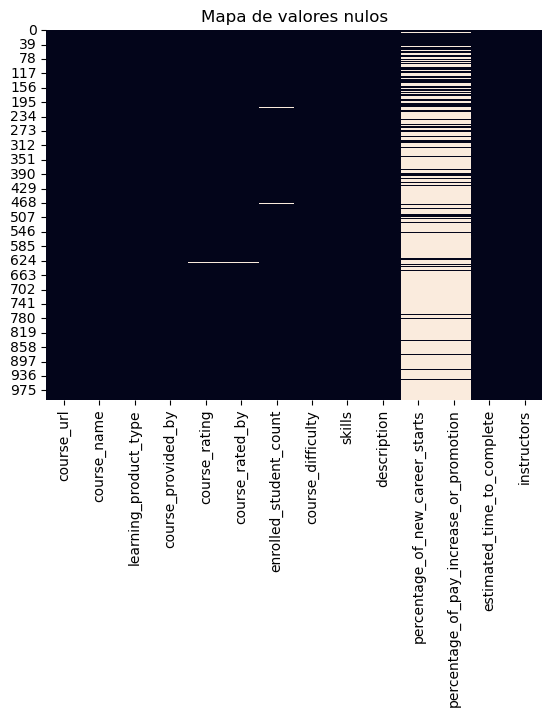

In [6]:
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

In [7]:
df.drop([
    'percentage_of_new_career_starts',
    'percentage_of_pay_increase_or_promotion'
], axis=1, inplace=True)

In [8]:
df['course_rating'] = df['course_rating'].fillna(df['course_rating'].mean())
df['course_rated_by'] = df['course_rated_by'].fillna(0)
df['enrolled_student_count'] = df['enrolled_student_count'].fillna(0)

In [9]:
df.isna().sum()

course_url                    0
course_name                   0
learning_product_type         0
course_provided_by            0
course_rating                 0
course_rated_by               0
enrolled_student_count        0
course_difficulty             0
skills                        0
description                   0
estimated_time_to_complete    0
instructors                   0
dtype: int64

In [10]:
tfidf = TfidfVectorizer(stop_words='english')

matriz = tfidf.fit_transform(df['skills'])

In [11]:
modelo = NearestNeighbors(metric='cosine', algorithm='brute')
modelo.fit(matriz)

NearestNeighbors(algorithm='brute', metric='cosine')

In [17]:
def recomendar_cursos(nome_curso, n=5):
    if nome_curso not in df['course_name'].values:
        return "Curso não encontrado"
    
    idx = df[df['course_name'] == nome_curso].index[0]
    
    distancias, indices = modelo.kneighbors(matriz[idx], n_neighbors=n+1)
    
    recomendados = df.iloc[indices[0][1:]]['course_name']
    return recomendados
    
    distancias, indices = modelo.kneighbors(matriz[idx], n_neighbors=n+1)
    
    recomendados = df.iloc[indices[0][1:]]['course_name']
    return recomendados

# Teste
recomendar_cursos("Data Science")

17     Data Science: Foundations using R
924            Getting and Cleaning Data
329                        R Programming
951       A Crash Course in Data Science
253         The Data Scientist’s Toolbox
Name: course_name, dtype: object